# 08 · Differentiate the calculation

**Time:** 100–120 minutes. **Preparation:** Lecture 07, product and chain rules, basic Python classes. **Lab:** [Forward-mode differentiation](../labs/lab08_automatic_differentiation.ipynb).

Objectives: propagate values and derivatives together, distinguish differentiation error from arithmetic error, and obtain interval derivative bounds. Two forward passes will give a small Jacobian. We keep the operation set small enough to inspect every rule.

In [1]:
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from flint import arb, ctx
from vc.intervals import RationalInterval as Interval
from vc.autodiff import Dual, jacobian2
from vc.arb_bridge import to_ball, from_ball

def polynomial(x):
    return x*x*x - 2*x

## EXPERIMENT · A derivative without a step size

At x=1 the derivative of x³−2x is 1. Forward differences subtract two nearby function values and divide by h. Their truncation error here is exactly 3h+h² in real arithmetic; floating-point rounding adds another error. Predict the behavior as h decreases.

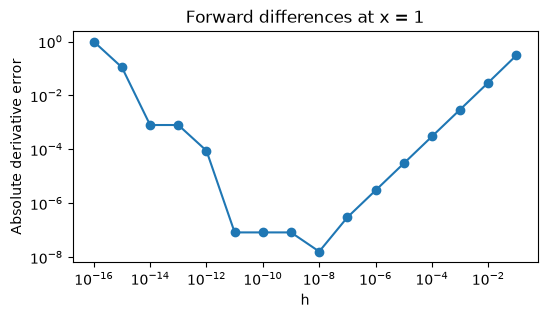

In [2]:
steps = 10.0 ** (-np.arange(1, 17))
errors = []
for h in steps:
    estimate = (polynomial(1.0 + h) - polynomial(1.0)) / h
    errors.append(abs(estimate - 1.0))
fig, ax = plt.subplots(figsize=(6, 3))
ax.loglog(steps, errors, "o-")
ax.set(xlabel="h", ylabel="Absolute derivative error", title="Forward differences at x = 1")
display(fig)
plt.close(fig)

## THEORY · Store a value and a tangent

A dual number is a pair (v, d), written formally v+dε with ε²=0. The first component stores a function value; the second stores its derivative with respect to a selected input direction. Multiplication gives

$$(v+d\varepsilon)(w+e\varepsilon)=vw+(dw+ve)\varepsilon.$$

This is the product rule. Addition gives (v+w, d+e). For a reciprocal, provided v≠0, the pair is (1/v, −d/v²). A differentiable elementary function g gives (g(v), g′(v)d).

**Why it works:** seed the independent variable with derivative 1 and constants with derivative 0. Induct along the expression using the usual differentiation rules. This differentiates the real expression represented by the program. With floating-point components, its computed value and derivative can still suffer rounding. It does not differentiate the discontinuous mapping of machine rounding itself.

In [3]:
# A visible product rule, before using operator overloading.
def multiply_pairs(left_value, left_derivative, right_value, right_derivative):
    value = left_value * right_value
    first_term = left_derivative * right_value
    second_term = left_value * right_derivative
    derivative = first_term + second_term
    return value, derivative

print(multiply_pairs(Fraction(2), Fraction(1), Fraction(3), Fraction(0)))
x = Dual(Fraction(1), Fraction(1))
result = polynomial(x)
print(result)
assert result.value == -1
assert result.derivative == 1

(Fraction(6, 1), Fraction(3, 1))
Dual(value=-1, derivative=1)


## THEORY · The arithmetic components determine the guarantee

The class [vc/autodiff.py](../vc/autodiff.py) stores `value` and `derivative` and applies these rules directly. Constants are lifted with zero tangent; powers are repeated multiplication by a nonnegative integer count. This implementation favors visible rules over efficiency.

If the two components are rigorous intervals, each operation encloses the corresponding real value and derivative for every input in the original interval. The same induction proves inclusion. Dependency can make either component wider than its actual range.

**Conditions:** every operation must be differentiable on the whole relevant domain; all component operations and input conversions must preserve inclusion. A ball return type alone cannot establish these conditions. Division needs a denominator excluding zero. We do not implement branch analysis, absolute value at zero, or arbitrary NumPy functions.

In [4]:
domain = Interval(1, 2)
result = polynomial(Dual(domain, Interval(1)))
print("Function enclosure:", result.value)
print("Derivative enclosure:", result.derivative)
# The analytic derivative 3*x² - 2 ranges from 1 to 10 on this domain.
assert Interval(1, 10).is_subset_of(result.derivative)

point = Dual(1.0, 1.0)
print("Floating-point AD experiment:", polynomial(point))

Function enclosure: [-3, 6]
Derivative enclosure: [1, 10]
Floating-point AD experiment: Dual(value=-1.0, derivative=1.0)


**CHECKPOINT (10 minutes):** derive the reciprocal rule by differentiating v·(1/v)=1. Explain why replacing interval components with 1,000-digit approximations does not automatically provide a derivative enclosure.

## EXPERIMENT · Elementary functions through Arb

The methods `exp`, `sin`, and `cos` use the Arb methods of their value component. They are not generic wrappers around Python `math`. Both value and tangent remain balls until exact endpoint conversion. The function below is differentiable on all real inputs, so the small widening when constructing the input ball is harmless.

In [5]:
def oscillating_exponential(x):
    return x.exp() * x.sin()

def value_and_derivative(domain, precision=100):
    with ctx.workprec(precision):
        input_ball = to_ball(domain)
        output = oscillating_exponential(Dual(input_ball, arb(1)))
        value_bound = from_ball(output.value)
        derivative_bound = from_ball(output.derivative)
    return value_bound, derivative_bound

value_bound, derivative_bound = value_and_derivative(Interval("-1/4", "1/4"))
print("Value bounds:", value_bound)
print("Derivative endpoint display ≈", float(derivative_bound.lo), float(derivative_bound.hi))
assert value_bound.contains(0)
assert derivative_bound.contains(1)  # f′(0)=1, an independent check.

Value bounds: [-6144688993730153538475531/19342813113834066795298816, 6144688993730152431004149/19342813113834066795298816]
Derivative endpoint display ≈ 0.4290636650199381 1.6016983969981162


## THEORY · A Jacobian one column at a time

For F(x,y)=(x²+y²−1, x−y), the Jacobian is

$$J_F(x,y)=\begin{pmatrix}2x&2y\\1&-1\end{pmatrix}.$$

Seed the input tangents (1,0) to obtain the first column; seed (0,1) for the second. Each output tangent is one directional derivative. Rows correspond to output equations and columns to input variables. The two-pass helper is short enough to read in full.

In [6]:
def system(x, y):
    return [x*x + y*y - 1, x-y]

box = [Interval(1, 2), Interval(3, 4)]
matrix = jacobian2(system, box)
for row in matrix:
    print(row)
assert matrix[0][0].lo == 2 and matrix[0][0].hi == 4
assert matrix[0][1].lo == 6 and matrix[0][1].hi == 8
assert matrix[1][0].lo == matrix[1][0].hi == 1
assert matrix[1][1].lo == matrix[1][1].hi == -1

[[2, 4], [6, 8]]
[[1, 1], [-1, -1]]


## Failure boundary · A branch is a mathematical decision

The formula `x if x > 0 else -x` implements |x| for real point inputs. A box crossing zero follows more than one branch and includes a point where the derivative does not exist. Choosing a branch from the midpoint cannot certify a derivative on that box.

Our class rejects truth testing, and comparisons are unsupported. More advanced AD systems can differentiate along a selected execution path, but that does not settle the interval-wide branch question.

In [7]:
try:
    bool(Dual(Interval(-1, 1), Interval(1)))
except TypeError as error:
    print("Expected limitation:", error)
try:
    Dual(Interval(-1, 1), Interval(1)).reciprocal()
except ZeroDivisionError as error:
    print("Expected domain rejection:", error)

Expected limitation: Branching on a dual number needs a separate analysis
Expected domain rejection: Reciprocal requires an interval excluding zero


## Exit ticket and reading

Explain three distinct objects: a finite-difference approximation, a floating-point AD result, and an interval AD enclosure. Which errors or assumptions remain in each?

**Reading:** Tucker §4.1, printed pp. 60–64. Higher derivatives in §§4.2–4.3 are extensions. Next: [validated roots](09_validated_roots.ipynb).